# Regressió ML amb Sklearn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score


## Càrrega de dades

Aquestes dades han d'estar netes i preparades per aplicar ML.

En aquest exemple de `tips`, volem predir la propina (`tip`) que pagarà un client.

In [4]:
# Cargar el dataset original de casas
df = pd.read_csv('data/house_pricing.csv')

# Filtrar para quedarnos únicamente con los datos etiquetados (proceso de ML)
df_labeled = df[df['Split'] == 'labeled'].copy()

# Separar características (X) y objetivo (y)
# Eliminamos 'SalePrice', 'Split' y el 'Id' (que es un mero identificador numérico)
X = df_labeled.drop(['SalePrice', 'Split', 'Id'], axis=1)
y = df_labeled['SalePrice']

## Pipeline de Feature Engineering

Defineix els passos de preprocessament per als models que ho necessiten.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [6]:
onehot_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')),
])

In [8]:
# Identificar tipos de columnas de manera automática y segura para Pandas 2/3
cat_features = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Tuberías independientes
cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Combinador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='drop'
)

# Pipeline final que asocia preprocesamiento + modelo regresor
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LinearRegression(n_jobs=-1))
])

## Train / Test

- Podem emular dades no vistes dividint les nostres dades en conjunts de **train** i de **test**.
    - Usem el conjunt d'entrenament per ajustar (entrenar) el nostre model.
    - Usem el conjunt de test per avaluar el rendiment del model amb dades no vistes.
- Les mides de test habituals són del 10-30% de les dades inicials.
    - Els conjunts de dades grans poden requerir un percentatge menor (p. ex., 10-20%).
    - Els conjunts de dades petits poden necessitar un conjunt de test més gran per garantir que sigui representatiu (p. ex., 30-40%).

In [6]:
from sklearn.model_selection import train_test_split, cross_validate, KFold

In [7]:
# Crear la variable X amb les característiques predictores (sense l'objectiu!)
X = df.drop('tip', axis=1)

# Separar l'objectiu en la variable `y`
y = df['tip']

# Divisió Entrenament / Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # 20% de les dades en el test
    shuffle=True,
    random_state=42
)

### Cross-validation

Definim l'objecte per aplicar cross-validation. Un cop definit, tots els models l'utilitzaran i, per tant, tots aplicaran el mateix tipus de CV. Això és útil perquè si apliquem un CV diferent a tots els models, no podríem comparar els resultats entre ells.

In [9]:
# Definim CV
# Diccionario para almacenar los resultados de cada grupo
cv_results = {}

# Evaluamos con 3, 5 y 10 pliegues (folds)
folds_to_test = [3, 5, 10]

print("=== EJECUTANDO CROSS-VALIDATION ===")
for k in folds_to_test:
    # Calculamos el MAE usando validación cruzada
    scores = cross_val_score(
        model_pipeline,
        X,
        y,
        cv=k,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    # Convertimos a valores positivos de MAE
    mae_scores = -scores
    cv_results[f'{k}-Folds'] = mae_scores

    print(f"\nConfiguración con {k} grupos:")
    print(f"  -> Errores en cada iteración: {np.round(mae_scores, 1)}")
    print(f"  -> MAE Medio: {mae_scores.mean():.1f} $ (Desviación Estándar: {mae_scores.std():.1f} $)")

=== EJECUTANDO CROSS-VALIDATION ===

Configuración con 3 grupos:
  -> Errores en cada iteración: [13331.5 14190.7 14240.2]
  -> MAE Medio: 13920.8 $ (Desviación Estándar: 417.2 $)

Configuración con 5 grupos:
  -> Errores en cada iteración: [13677.9 12497.2 14204.1 13757.8 14588.6]
  -> MAE Medio: 13745.1 $ (Desviación Estándar: 704.9 $)

Configuración con 10 grupos:
  -> Errores en cada iteración: [12464.8 15308.4 12544.6 11832.8 12369.8 15965.3 14442.2 12743.5 13346.2
 15795.1]
  -> MAE Medio: 13681.3 $ (Desviación Estándar: 1476.9 $)


## Entrenament del model

In [9]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

### Baseline

- Entrena i avalua el rendiment d'un model de referència (baseline).
- Proporciona una mesura inicial del rendiment.
- Qualsevol model que desenvolupis hauria de superar aquesta línia base simple.

In [10]:
from sklearn.dummy import DummyRegressor

In [11]:
# El baseline predirà sempre el valor mitjà de la columna target
bl = DummyRegressor(strategy='mean')

# Entrenar
bl_cv = cross_validate(
    bl,
    X_train,
    y_train,
    cv=kfold,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    n_jobs=-1
)

In [12]:
bl_cv

{'fit_time': array([0.00407791, 0.00658536, 0.00698805, 0.00515842, 0.00738597,
        0.00296187, 0.00546932, 0.007936  , 0.00308633, 0.00394678]),
 'score_time': array([0.00117493, 0.00250602, 0.00228643, 0.00310946, 0.0015173 ,
        0.00084114, 0.00079536, 0.00206947, 0.00104904, 0.00167871]),
 'test_score': array([-1.34441429, -0.75078286, -0.90314286, -0.99909143, -0.6495    ,
        -1.00163278, -1.07003589, -1.15882177, -1.24207237, -1.4874372 ]),
 'train_score': array([-1.02443102, -1.09517714, -1.07723102, -1.05826351, -1.09793894,
        -1.05050232, -1.05916581, -1.03905992, -1.02695313, -0.99436467])}

In [13]:
avg_train_mae = -bl_cv['train_score'].mean()
avg_val_mae = -bl_cv['test_score'].mean()  # Validation score

print(f'Avg. train MAE: {avg_train_mae:.1f}')
print(f'Avg. val. MAE: {avg_val_mae:.1f}')

Avg. train MAE: 1.1
Avg. val. MAE: 1.1


### Regressió lineal

- Cada vegada que entrenem la regressió lineal,
- el model aprèn els coeficients $w_i$ (en funció de les característiques $x_i$):

    $\hat{y} = w_0 + w_1 \cdot x_1 + w_2 \cdot x_2 + \text{...} + w_n \cdot x_n$


- de manera que les prediccions $\hat{y}$ minimitzin $MSE(y, \hat{y})$.

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
# Definim una Pipeline que primer processarà les dades i llavors aplicarà LR
lr = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LinearRegression(n_jobs=-1))
])

# Entrenar
lr_cv = cross_validate(
    lr,
    X_train,
    y_train,
    cv=kfold,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    n_jobs=-1
)

In [16]:
avg_train_mae = -lr_cv['train_score'].mean()
avg_val_mae = -lr_cv['test_score'].mean()

print(f'Avg. train MAE: {avg_train_mae:.1f}')
print(f'Avg. val. MAE: {avg_val_mae:.1f}')

Avg. train MAE: 0.8
Avg. val. MAE: 0.8


C:\Users\fundacion\AppData\Local\Temp\ipykernel_15216\4101984141.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Configuración', y='MAE ($)', data=df_plot, ax=axes[0], palette='Set2')


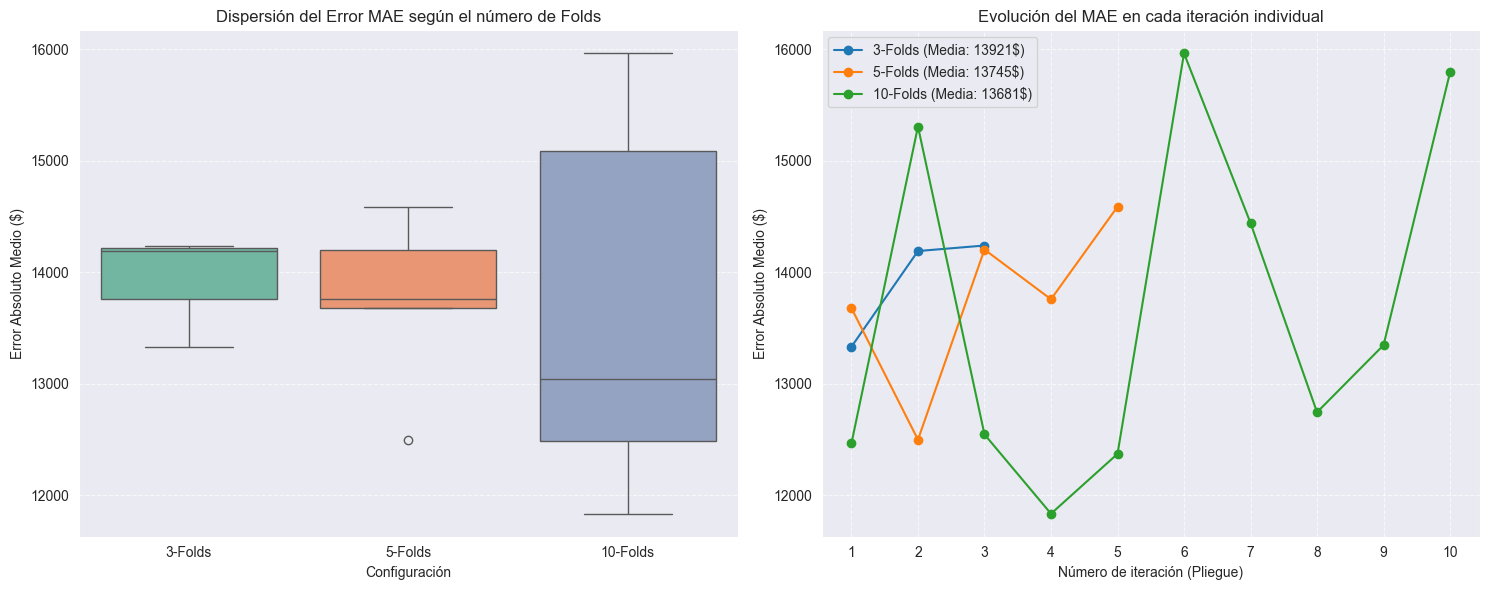

In [10]:
# Convertimos los resultados a un DataFrame para graficar fácilmente
# Como tienen longitudes diferentes (3, 5 y 10 datos), creamos la estructura adecuada
plot_data = []
for k, scores in cv_results.items():
    for score in scores:
        plot_data.append({'Configuración': k, 'MAE ($)': score})
df_plot = pd.DataFrame(plot_data)

# Crear la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfica 1: Boxplot (Permite ver la estabilidad del modelo)
sns.boxplot(x='Configuración', y='MAE ($)', data=df_plot, ax=axes[0], palette='Set2')
axes[0].set_title('Dispersión del Error MAE según el número de Folds')
axes[0].set_ylabel('Error Absoluto Medio ($)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfica 2: Gráfico de líneas (Para observar cada iteración individual)
for k, scores in cv_results.items():
    axes[1].plot(range(1, len(scores) + 1), scores, marker='o', label=f'{k} (Media: {scores.mean():.0f}$)')
axes[1].set_title('Evolución del MAE en cada iteración individual')
axes[1].set_xlabel('Número de iteración (Pliegue)')
axes[1].set_ylabel('Error Absoluto Medio ($)')
axes[1].set_xticks(range(1, 11))
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()